In [1]:
#MIWAF PHASE 2 - MACHINE LEARNING 
#Notebook 2: Well Contamination Classifier
#Author: Mbugua Hellen Njeri | Reg no 24/05982
#Description : Predict whether a well is contaminated using Logistic Regression, Random Forest and XGBoost

In [2]:
# Import libraries needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

#Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix,roc_auc_score)
from xgboost import XGBClassifier
print("All libraries imported")

All libraries imported


In [3]:
#Load the Dataset
#Load Model 1 dataset from Notebook
notebook_dir = os.getcwd()
outputs_dir = os.path.join(notebook_dir,'outputs')
models_dir = os.path.join(notebook_dir,'models')

os.makedirs(models_dir, exist_ok=True)
#Load data
df = pd.read_csv(
    os.path.join(outputs_dir, 'model1_contamination_data.csv')
)
print(f"   Shape : {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nContamination breakdown:")
print(df['is_contaminated'].value_counts())

   Shape : (17383, 4)

First 5 rows:
   pollutant_ppm  biological  is_contaminated contamination_type
0       0.000000  495.898000                1         Biological
1       0.000000    6.096080                1         Biological
2       2.715000    0.000000                1           Chemical
3       0.028859    0.000096                0              Clean
4       0.000000   22.500900                1         Biological

Contamination breakdown:
is_contaminated
1    12467
0     4916
Name: count, dtype: int64


In [4]:
#Split into Features and Targets
#Separate inputs(x) from the answer we want to predict(Y)
#X= input the model learns from
X = df[['pollutant_ppm','biological']]

#Y = the answer we want to predict
y = df['is_contaminated']
print(f" X shape: {X.shape}")
print(f" y shape: {y.shape}")
print(f"\nx (first 5 rows)")
print(X.head())
print(f"\ny (first 5 values)")
print(y.head())

 X shape: (17383, 2)
 y shape: (17383,)

x (first 5 rows)
   pollutant_ppm  biological
0       0.000000  495.898000
1       0.000000    6.096080
2       2.715000    0.000000
3       0.028859    0.000096
4       0.000000   22.500900

y (first 5 values)
0    1
1    1
2    1
3    0
4    1
Name: is_contaminated, dtype: int64


In [5]:
# Split data into training set and testing set
# 80% for training - Model learns from this 
#20% for testing - we test on data model has never seen

X_train, X_test,y_train,y_test = train_test_split(
    X,y, test_size= 0.2,    #20% for testing
    random_state= 42, # makes results reproducible
    stratify= y          # keeps ratio same in both sets
)
print(f" Training set: {X_train.shape[0]} rows(80%)")
print(f" Testing set : {X_test.shape[0]} rows(20%) ")
print(f"\nContamination ratio in training set:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nContamination ratio in testing set:")
print(y_test.value_counts(normalize=True).round(3))

 Training set: 13906 rows(80%)
 Testing set : 3477 rows(20%) 

Contamination ratio in training set:
is_contaminated
1    0.717
0    0.283
Name: proportion, dtype: float64

Contamination ratio in testing set:
is_contaminated
1    0.717
0    0.283
Name: proportion, dtype: float64


In [6]:
# Scale features so both columns are on the same scale
# pollutant_ppm ranges 0-10 biological ranges 0-500 Without scaling the model thinks biological is more important just because the numbers are bigger!

scaler  = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


print(f"   Before scaling - biological mean : "
      f"{X_train['biological'].mean():.2f}")
print(f"   After scaling  - biological mean : "
      f"{X_train_scaled[:, 1].mean():.4f}")

# Save scaler for Streamlit app later
with open(os.path.join(models_dir, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

   Before scaling - biological mean : 73.14
   After scaling  - biological mean : 0.0000


In [8]:
#Train the Model - Logistic Regression
print("Training Logistic Regression")

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

#Make predictions on test 
lr_predictions = lr_model.predict(X_test_scaled)

#Measure Accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_auc = roc_auc_score(y_test, lr_predictions)

print(f"Accuracy : {lr_accuracy*100:.2f}%")
print(f"AUC Score: {lr_auc:.4f}")
print(f"\nDetailed Report:")
print(classification_report(y_test, lr_predictions,target_names=['Clean','Contaminated']))


Training Logistic Regression
Accuracy : 97.96%
AUC Score: 0.9858

Detailed Report:
              precision    recall  f1-score   support

       Clean       0.93      1.00      0.97       983
Contaminated       1.00      0.97      0.99      2494

    accuracy                           0.98      3477
   macro avg       0.97      0.99      0.98      3477
weighted avg       0.98      0.98      0.98      3477



In [10]:
#Train the model using Random Forest
#Builds a 100 decision trees and takes a vote
print('Training using Random Forest Algorithm')
rf_model = RandomForestClassifier(
    n_estimators=100,  #100trees
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)
#make predictions
rf_predictions = rf_model.predict(X_test_scaled)
#Measure the accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_auc = roc_auc_score(y_test, rf_predictions)
print(f"Accuracy : {rf_accuracy*100:.2f}%")
print(f" AUC Score: {rf_auc:.4f}")
print(f"\nDetailed Report:")
print(classification_report(y_test,rf_predictions,target_names=['Clean', 'Contaminated']))

Training using Random Forest Algorithm
Accuracy : 100.00%
 AUC Score: 1.0000

Detailed Report:
              precision    recall  f1-score   support

       Clean       1.00      1.00      1.00       983
Contaminated       1.00      1.00      1.00      2494

    accuracy                           1.00      3477
   macro avg       1.00      1.00      1.00      3477
weighted avg       1.00      1.00      1.00      3477



In [12]:
#Training using XGBoost 
print('Traing using XGBoost Algorithm')
xgb_model = XGBClassifier(
    n_estimators = 100,
    random_state = 42,
    eval_metric = 'logloss',
    verbosity = 0
)
xgb_model.fit(X_train_scaled, y_train)

#Make predictions
xgb_predictions = xgb_model.predict(X_test_scaled)
#Measure accuracy
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_auc = roc_auc_score(y_test, xgb_predictions)

print(f" Accuracy : {xgb_accuracy*100:.2f}%")
print(f"AUC Score: {xgb_auc:.4f}")
print(f"\nDetailed Report")
print(classification_report(y_test, xgb_predictions, target_names=['Clean', 'Contaminated']))

Traing using XGBoost Algorithm
 Accuracy : 100.00%
AUC Score: 1.0000

Detailed Report
              precision    recall  f1-score   support

       Clean       1.00      1.00      1.00       983
Contaminated       1.00      1.00      1.00      2494

    accuracy                           1.00      3477
   macro avg       1.00      1.00      1.00      3477
weighted avg       1.00      1.00      1.00      3477



In [14]:
#Comparing all the 3 models
results = pd.DataFrame({
    'Model' : ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy' : [lr_accuracy*100, rf_accuracy * 100, xgb_accuracy * 100],
    'AUC Score' : [lr_auc, rf_auc, xgb_auc]
})
results['Accuracy'] = results['Accuracy'].round(2)
results['AUC Score'] = results['AUC Score'].round(4)
results=results.sort_values('Accuracy', ascending=False)

print("=" * 45)
print(" MODEL COMPARISION - CONTAMINATION")
print("=" *45)
print(results.to_string(index=False))
print(f"\n Best Model: {results.iloc[0]['Model']}")
print(f"\n Accuracy: {results.iloc[0]['Accuracy']}")
print(f"\n AUC Score: {results.iloc[0]['AUC Score']}")

 MODEL COMPARISION - CONTAMINATION
              Model  Accuracy  AUC Score
      Random Forest    100.00     1.0000
            XGBoost    100.00     1.0000
Logistic Regression     97.96     0.9858

 Best Model: Random Forest

 Accuracy: 100.0

 AUC Score: 1.0


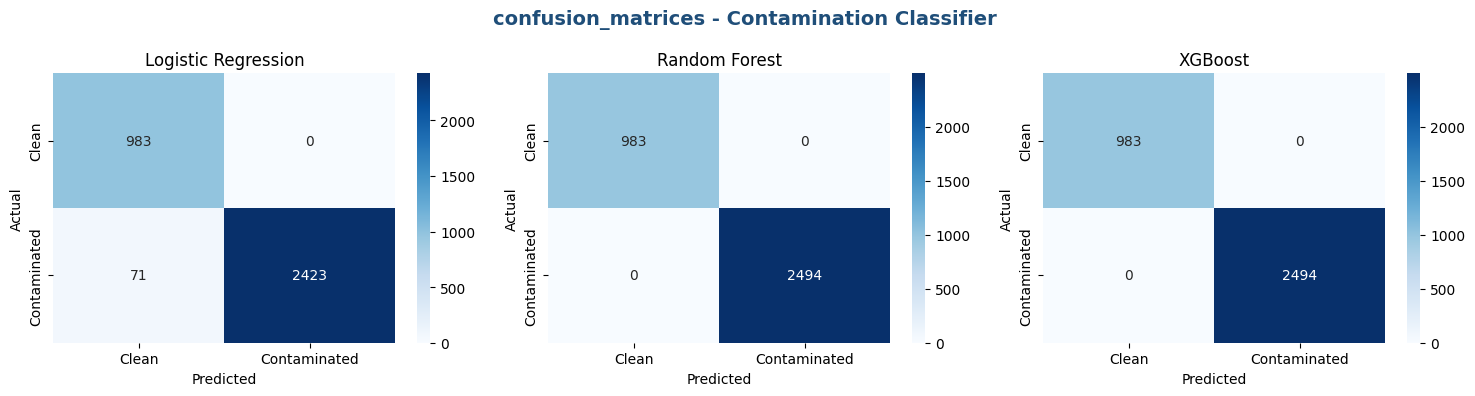

In [16]:
#Confusion Matrix for best model (XGBoost)
#Shows exactly where the model gets it right and wrong
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    'confusion_matrices - Contamination Classifier', fontsize = 14, fontweight = 'bold', color = '#1F4E79'
)
models_list = [
    ('Logistic Regression', lr_predictions),
    ('Random Forest', rf_predictions),
    ('XGBoost', xgb_predictions)
]
for ax, (name, preds) in zip(axes, models_list):
    cm = confusion_matrix(y_test,preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Clean', 'Contaminated'], yticklabels=['Clean', 'Contaminated']
    )
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(
    os.path.join(outputs_dir, 'confusion_matrix.png'), dpi=150, bbox_inches = 'tight'
)
plt.show()


In [17]:
#Save the Best Model
# Save the best performing model for Streamlit app

# Determine best model automatically
best_accuracy = max(lr_accuracy, rf_accuracy, xgb_accuracy)

if best_accuracy == xgb_accuracy:
    best_model      = xgb_model
    best_model_name = 'XGBoost'
elif best_accuracy == rf_accuracy:
    best_model      = rf_model
    best_model_name = 'Random Forest'
else:
    best_model      = lr_model
    best_model_name = 'Logistic Regression'

# Save best model
with open(
    os.path.join(models_dir, 'contamination_model.pkl'), 'wb'
) as f:
    pickle.dump(best_model, f)

print(f"   Model    : {best_model_name}")
print(f"   Accuracy : {best_accuracy*100:.2f}%")
print(f"   Saved to : models/contamination_model.pkl")
print(f"\n Next → Notebook 03: Queue Time Regressor")

   Model    : XGBoost
   Accuracy : 100.00%
   Saved to : models/contamination_model.pkl

 Next → Notebook 03: Queue Time Regressor
